In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported")


Libraries imported


In [2]:
df = pd.read_csv('data.csv')
print("Shape:", df.shape)

df.drop(columns=['Unnamed: 32', 'id'], inplace=True)

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("Cleaned shape:", df.shape)
print(f"\nClass distribution:")
print(df['diagnosis'].value_counts().rename({1:'Malignant', 0:'Benign'}))
print(f"\nMalignant %: {df['diagnosis'].mean()*100:.1f}%")
df.head()


Shape: (569, 33)
Cleaned shape: (569, 31)

Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Malignant %: 37.3%


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Statistical Summary (first 5 features):")
df.describe().iloc[:, :5].round(3)


Statistical Summary (first 5 features):


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean
count,569.000,569.000,569.000,569.000,569.000
mean,0.373,14.127,19.290,91.969,654.889
std,0.484,3.524,4.301,24.299,351.914
min,0.000,6.981,9.710,43.790,143.500
25%,0.000,11.700,16.170,75.170,420.300
50%,0.000,13.370,18.840,86.240,551.100
75%,1.000,15.780,21.800,104.100,782.700
max,1.000,28.110,39.280,188.500,2501.000


In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values after dropping Unnamed: 32")
else:
    print("Missing values found:")
    print(missing)


No missing values after dropping Unnamed: 32


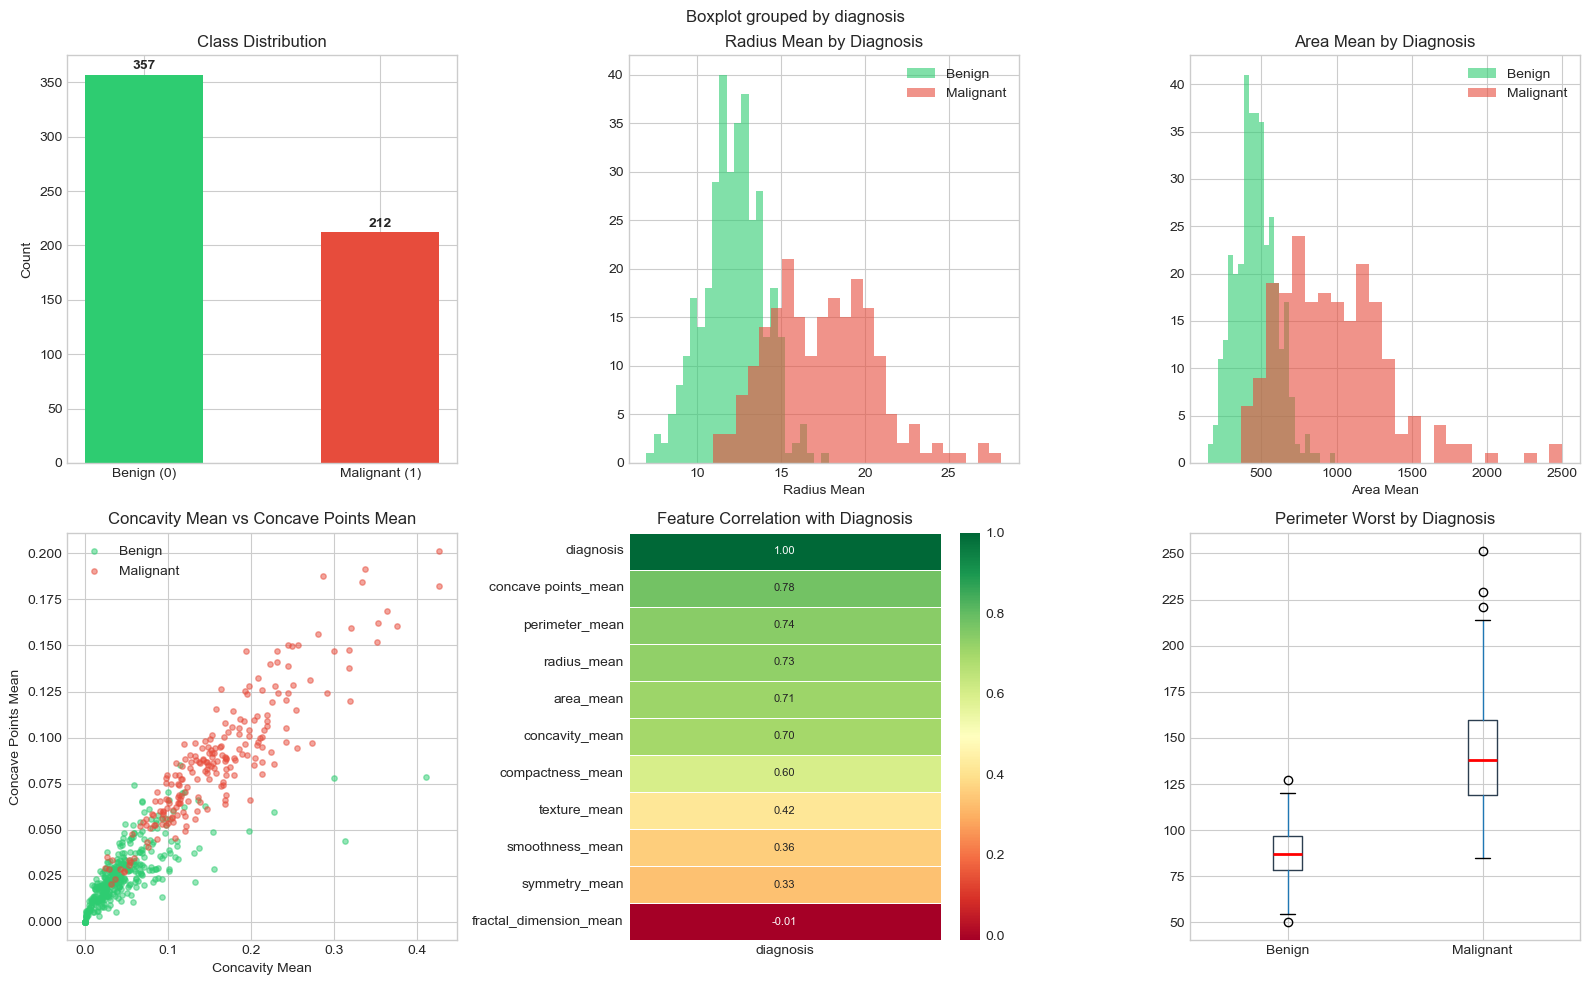

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Breast Cancer Dataset — EDA', fontsize=16, fontweight='bold')

colors = {1: '#e74c3c', 0: '#2ecc71'}
labels = {1: 'Malignant', 0: 'Benign'}

counts = df['diagnosis'].value_counts()
axes[0,0].bar(['Benign (0)', 'Malignant (1)'], [counts[0], counts[1]],
               color=['#2ecc71','#e74c3c'], width=0.5)
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0,0].text(i, v+5, str(v), ha='center', fontweight='bold')

for diag in [0, 1]:
    axes[0,1].hist(df[df['diagnosis']==diag]['radius_mean'],
                   bins=25, alpha=0.6, label=labels[diag], color=colors[diag])
axes[0,1].set_title('Radius Mean by Diagnosis')
axes[0,1].set_xlabel('Radius Mean')
axes[0,1].legend()

for diag in [0, 1]:
    axes[0,2].hist(df[df['diagnosis']==diag]['area_mean'],
                   bins=25, alpha=0.6, label=labels[diag], color=colors[diag])
axes[0,2].set_title('Area Mean by Diagnosis')
axes[0,2].set_xlabel('Area Mean')
axes[0,2].legend()

axes[1,0].scatter(df[df['diagnosis']==0]['concavity_mean'],
                  df[df['diagnosis']==0]['concave points_mean'],
                  alpha=0.5, color='#2ecc71', s=15, label='Benign')
axes[1,0].scatter(df[df['diagnosis']==1]['concavity_mean'],
                  df[df['diagnosis']==1]['concave points_mean'],
                  alpha=0.5, color='#e74c3c', s=15, label='Malignant')
axes[1,0].set_title('Concavity Mean vs Concave Points Mean')
axes[1,0].set_xlabel('Concavity Mean')
axes[1,0].set_ylabel('Concave Points Mean')
axes[1,0].legend()

mean_cols = [c for c in df.columns if '_mean' in c] + ['diagnosis']
corr = df[mean_cols].corr()
sns.heatmap(corr[['diagnosis']].sort_values('diagnosis', ascending=False),
            annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1,1],
            linewidths=0.5, annot_kws={'size':8})
axes[1,1].set_title('Feature Correlation with Diagnosis')

df.boxplot(column='perimeter_worst', by='diagnosis', ax=axes[1,2],
           boxprops=dict(color='#2c3e50'), medianprops=dict(color='red', lw=2))
plt.sca(axes[1,2])
plt.title('Perimeter Worst by Diagnosis')
axes[1,2].set_xticklabels(['Benign','Malignant'])
axes[1,2].set_xlabel('')

plt.tight_layout()
plt.savefig('cancer_eda.png', dpi=120, bbox_inches='tight')
plt.show()


In [6]:
mean_cols = [c for c in df.columns if c != 'diagnosis']
corr_target = df[mean_cols].corrwith(df['diagnosis']).abs().sort_values(ascending=False)
print("Top 10 features most correlated with diagnosis (Malignant):")
print(corr_target.head(10).round(3))


Top 10 features most correlated with diagnosis (Malignant):
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
dtype: float64


In [7]:
df['radius_to_area']       = df['radius_mean'] / (df['area_mean'] + 1)
df['compactness_ratio']    = df['compactness_mean'] / (df['smoothness_mean'] + 1e-6)
df['worst_to_mean_radius'] = df['radius_worst'] / (df['radius_mean'] + 1e-6)
df['worst_to_mean_area']   = df['area_worst'] / (df['area_mean'] + 1e-6)
df['concavity_symmetry']   = df['concavity_mean'] * df['symmetry_mean']

new_feats = ['radius_to_area','compactness_ratio','worst_to_mean_radius',
             'worst_to_mean_area','concavity_symmetry']
print("New engineered features and correlation with diagnosis:")
for f in new_feats:
    r = df[f].corr(df['diagnosis'])
    print(f"  {f:28s}: {r:.3f}")


New engineered features and correlation with diagnosis:
  radius_to_area              : -0.695
  compactness_ratio           : 0.585
  worst_to_mean_radius        : 0.641
  worst_to_mean_area          : 0.621
  concavity_symmetry          : 0.651


In [8]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")
print(f"\nMalignant in test set: {y_test.sum()} / {len(y_test)}")


Training samples: 455
Test samples:     114
Features:         35

Malignant in test set: 42 / 114


In [9]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=200, random_state=42), False),
    'SVM (RBF)':           (SVC(kernel='rbf', probability=True, random_state=42), True),
    'KNN (k=5)':           (KNeighborsClassifier(n_neighbors=5), True),
}

results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, use_scale) in models.items():
    Xtr = X_train_sc if use_scale else X_train.values
    Xte = X_test_sc  if use_scale else X_test.values

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    results[name] = {
        'accuracy':  accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall':    recall_score(y_test, preds),   # ← most important metric
        'f1':        f1_score(y_test, preds),
        'roc_auc':   roc_auc_score(y_test,
                        model.predict_proba(Xte)[:,1] if hasattr(model,'predict_proba')
                        else model.decision_function(Xte)),
        'preds': preds, 'model': model,
        'use_scale': use_scale
    }
    r = results[name]
    print(f"{name:22s} | Acc: {r['accuracy']:.4f} | "
          f"Recall: {r['recall']:.4f} | F1: {r['f1']:.4f} | AUC: {r['roc_auc']:.4f}")


Logistic Regression    | Acc: 0.9737 | Recall: 0.9524 | F1: 0.9639 | AUC: 0.9974
Random Forest          | Acc: 0.9737 | Recall: 0.9286 | F1: 0.9630 | AUC: 0.9955
Gradient Boosting      | Acc: 0.9737 | Recall: 0.9286 | F1: 0.9630 | AUC: 0.9974
SVM (RBF)              | Acc: 0.9649 | Recall: 0.9048 | F1: 0.9500 | AUC: 0.9974
KNN (k=5)              | Acc: 0.9561 | Recall: 0.8810 | F1: 0.9367 | AUC: 0.9828


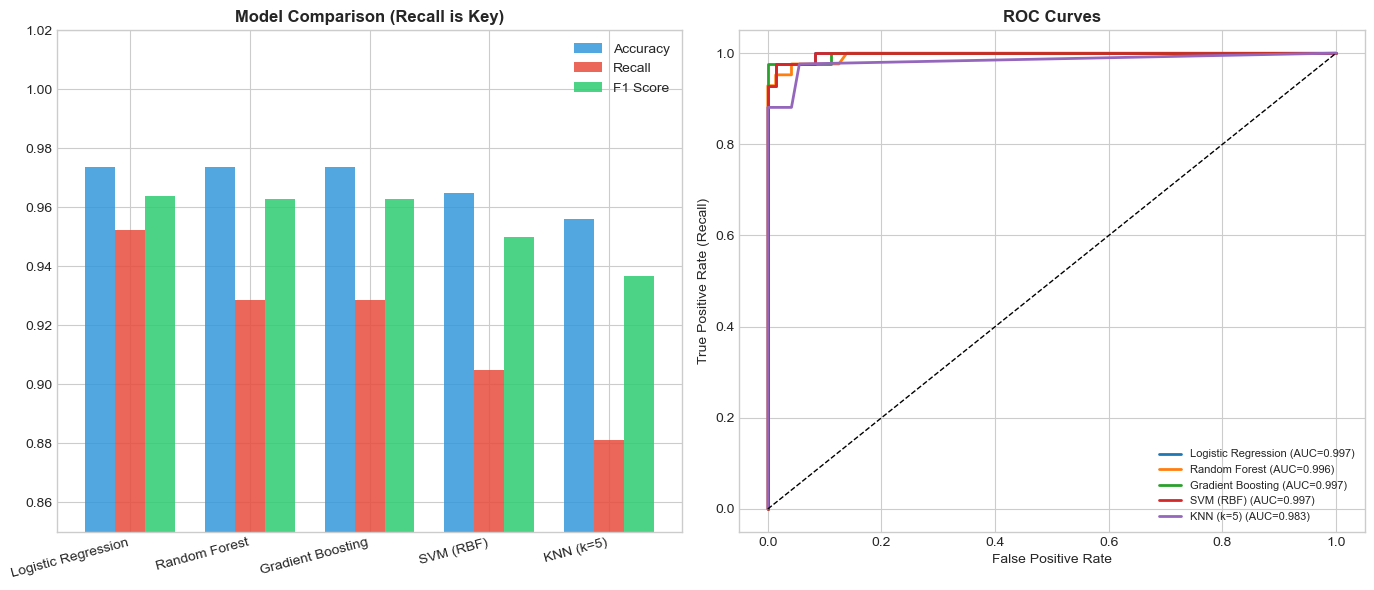


Best Model by Recall: Logistic Regression
  Recall:   0.9524  ← minimises missed cancers
  Accuracy: 0.9737
  F1:       0.9639
  AUC:      0.9974


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

names = list(results.keys())
recalls  = [results[n]['recall']  for n in names]
f1s      = [results[n]['f1']      for n in names]
aucs     = [results[n]['roc_auc'] for n in names]

x = np.arange(len(names))
w = 0.25

axes[0].bar(x - w, [results[n]['accuracy'] for n in names], w, label='Accuracy',   color='#3498db', alpha=0.85)
axes[0].bar(x,     recalls,                                  w, label='Recall',     color='#e74c3c', alpha=0.85)
axes[0].bar(x + w, f1s,                                      w, label='F1 Score',   color='#2ecc71', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylim(0.85, 1.02)
axes[0].set_title('Model Comparison (Recall is Key)', fontsize=12, fontweight='bold')
axes[0].legend()

for name, res in results.items():
    model = res['model']
    Xte = X_test_sc if res['use_scale'] else X_test.values
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(Xte)[:,1]
    else:
        proba = model.decision_function(Xte)
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC={res['roc_auc']:.3f})")

axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_title('ROC Curves', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('cancer_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

best_name = max(results, key=lambda k: results[k]['recall'])
print(f"\nBest Model by Recall: {best_name}")
print(f"  Recall:   {results[best_name]['recall']:.4f}  ← minimises missed cancers")
print(f"  Accuracy: {results[best_name]['accuracy']:.4f}")
print(f"  F1:       {results[best_name]['f1']:.4f}")
print(f"  AUC:      {results[best_name]['roc_auc']:.4f}")



True Positives  (Malignant correctly detected): 40
False Negatives (Malignant MISSED — dangerous!): 2
True Negatives  (Benign correctly identified):   71
False Positives (Benign flagged as Malignant):   1


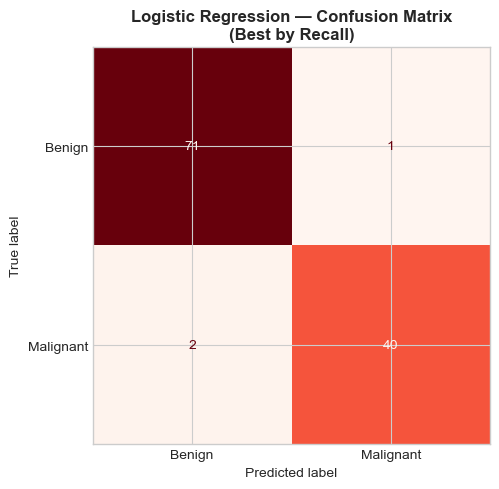

In [11]:
best = results[best_name]
Xte = X_test_sc if best['use_scale'] else X_test.values
cm = confusion_matrix(y_test, best['preds'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign','Malignant'])
disp.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title(f'{best_name} — Confusion Matrix\n(Best by Recall)', fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (Malignant correctly detected): {tp}")
print(f"False Negatives (Malignant MISSED — dangerous!): {fn}")
print(f"True Negatives  (Benign correctly identified):   {tn}")
print(f"False Positives (Benign flagged as Malignant):   {fp}")

plt.tight_layout()
plt.savefig('cancer_confusion.png', dpi=120, bbox_inches='tight')
plt.show()


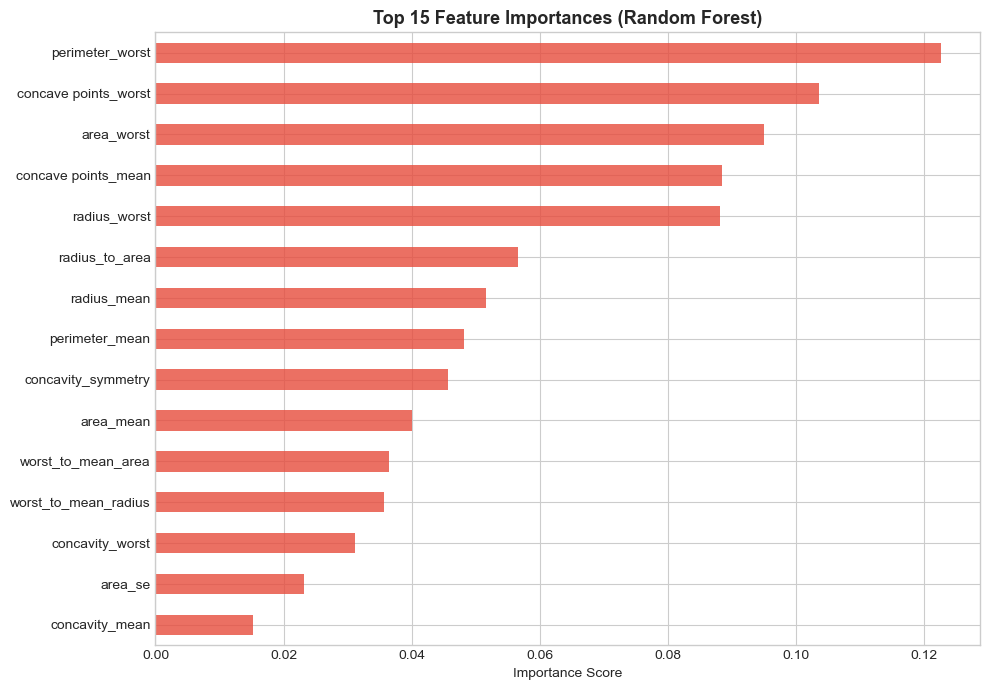

Top 5 most predictive features:
  concavity_mean                : 0.0153
  area_se                       : 0.0232
  concavity_worst               : 0.0311
  worst_to_mean_radius          : 0.0357
  worst_to_mean_area            : 0.0364


In [12]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 7))
top15.sort_values().plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8)
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('cancer_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 most predictive features:")
for feat, imp in top15.tail(5)[::-1].items():
    print(f"  {feat:30s}: {imp:.4f}")


In [14]:
print(f"Best Model: {best_name}\n")
print(classification_report(y_test, best['preds'],
                             target_names=['Benign','Malignant']))


Best Model: Logistic Regression

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

